## Set-up 

In [12]:
import os
import glob
import json
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from threadpoolctl import threadpool_limits
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# ---- 1. RÉGLAGES GLOBAUX ----
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ---- 2. CONFIGURATION DUCKDB ----
con = duckdb.connect()
con.execute("PRAGMA memory_limit='150GB'")
con.execute("PRAGMA threads=32") 

# ---- 3. CHARGEMENT DU MAPPING DES SOURCES ----
SOURCE_MAP_PATH = "/data/gdelt/gdelt_sources_mapping.json"
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "Src_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

In [16]:
# ---- 4. CRÉATION DIRECTE DE LA VUE GKG_RAW ----
print("⏳ Création de la vue 'gkg_raw' unique et optimisée...")

# Le 'r' devant les guillemets est important pour protéger les regex (\d et \.)
query_raw = r"""
    CREATE OR REPLACE VIEW gkg_raw AS
    
    WITH raw_prefiltered AS (
        -- 1. Filtres de base
        SELECT *
        FROM read_parquet('/data/gdelt/gdelt_parquet_db/gdelt_*.parquet')
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
    ),
    repaired_sources AS (
        -- 2. On exclut l'ancienne colonne et on crée 'Src_ID' réparé
        SELECT 
            r.* EXCLUDE (SourceCommonName_ID),
            COALESCE(NULLIF(r.SourceCommonName_ID, 0), m.Src_ID) AS Src_ID
        FROM raw_prefiltered r
        LEFT JOIN src_map m 
          ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
    )
    
    -- 3. Jointure avec ta whitelist qui utilise 'Src_ID'
    SELECT s.*
    FROM repaired_sources s
    INNER JOIN read_parquet('valid_sources_whitelist.parquet') w
      ON s.Src_ID = w.Src_ID;
"""

con.execute(query_raw)
print("✅ Base initialisée ! La vue 'gkg_raw' est prête.")

# ---- 4. CRÉATION DIRECTE DE LA VUE GKG_FINAL ----
print("⏳ Création de la vue 'gkg_final' unique et optimisée...")

query_final = """
    CREATE OR REPLACE VIEW gkg_final AS
    
    WITH raw_prefiltered AS (
        -- 1. Filtres allégés
        SELECT *
        FROM read_parquet('/data/gdelt/gdelt_parquet_db/gdelt_*.parquet')
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
          AND WordCount BETWEEN 15 AND 6500
          AND ARRAY_LENGTH(string_split(EnhancedThemes, ';')) >= 2
    ),
    repaired_sources AS (
        -- 2. On exclut le VIEUX nom (SourceCommonName_ID) de la base d'origine
        -- et on crée la NOUVELLE colonne (SourceCommonName_ID) réparée
        SELECT 
            r.* EXCLUDE (SourceCommonName_ID),
            COALESCE(NULLIF(r.SourceCommonName_ID, 0), m.Src_ID) AS Src_ID
        FROM raw_prefiltered r
        LEFT JOIN src_map m 
          ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
    )
    
    -- 3. Jointure avec ta whitelist qui utilise 'Src_ID'
    SELECT s.*
    FROM repaired_sources s
    INNER JOIN read_parquet('valid_sources_whitelist.parquet') w
      ON s.Src_ID = w.Src_ID;
"""

con.execute(query_final)

print("✅ Base initialisée ! La vue 'gkg_final' est prête.")

# ---- CRÉATION DE LA VUE GKG_WHITELIST_AND_WIKI (INTERSECTION) ----
print("⏳ Création de la vue 'gkg_wiki' (Ancienne whitelist ET Wikidata)...")

query_intersect = r"""
    CREATE OR REPLACE VIEW gkg_wiki AS
    
    WITH raw_prefiltered AS (
        SELECT *
        FROM read_parquet('/data/gdelt/gdelt_parquet_db/gdelt_*.parquet')
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
    ),
    repaired_sources AS (
        SELECT 
            r.* EXCLUDE (SourceCommonName_ID),
            COALESCE(NULLIF(r.SourceCommonName_ID, 0), m.Src_ID) AS Src_ID
        FROM raw_prefiltered r
        LEFT JOIN src_map m 
          ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
    )
    
    -- Double jointure INNER : le média doit être dans les DEUX listes
    SELECT 
        s.*,
        w.medialabel,
        w.typelabel,
        w.countrylabel,
        w.inception
    FROM repaired_sources s
    INNER JOIN read_parquet('valid_sources_whitelist.parquet') v
      ON s.Src_ID = v.Src_ID
    INNER JOIN (
        SELECT DISTINCT id AS Src_ID, medialabel, typelabel, countrylabel, inception
        FROM read_parquet('data/domains/domains_*.parquet')
    ) w ON s.Src_ID = w.Src_ID;
"""

con.execute(query_intersect)
print("✅ Vue 'gkg_wiki' créée avec succès !")

# ---- CRÉATION DE LA VUE DU RESTE (WHITELIST HISTORIQUE HORS WIKIDATA) ----
print("⏳ Création de la vue 'gkg_not_in_wiki' (Dans l'ancienne whitelist mais PAS dans Wikidata)...")

query_exclude = r"""
    CREATE OR REPLACE VIEW gkg_not_in_wiki AS
    
    WITH raw_prefiltered AS (
        SELECT *
        FROM read_parquet('/data/gdelt/gdelt_parquet_db/gdelt_*.parquet')
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
    ),
    repaired_sources AS (
        SELECT 
            r.* EXCLUDE (SourceCommonName_ID),
            COALESCE(NULLIF(r.SourceCommonName_ID, 0), m.Src_ID) AS Src_ID
        FROM raw_prefiltered r
        LEFT JOIN src_map m 
          ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
    )
    
    -- 1. On filtre d'abord sur ta whitelist historique (INNER JOIN)
    -- 2. On fait un LEFT JOIN sur Wikidata et on ne garde que ceux où le match a ÉCHOUÉ (IS NULL)
    SELECT 
        s.*,
        NULL AS medialabel,
        NULL AS typelabel,
        NULL AS countrylabel,
        NULL AS inception
    FROM repaired_sources s
    INNER JOIN read_parquet('valid_sources_whitelist.parquet') v
      ON s.Src_ID = v.Src_ID
    LEFT JOIN (
        SELECT DISTINCT id AS Src_ID
        FROM read_parquet('data/domains/domains_*.parquet')
    ) w ON s.Src_ID = w.Src_ID
    WHERE w.Src_ID IS NULL;
"""

con.execute(query_exclude)
print("✅ Vue 'gkg_not_in_wiki' créée avec succès !")

print("\n📊 Comparatif global des volumes d'articles selon la stratégie de filtrage :")
con.execute("""
    SELECT '1. gkg_raw (Ancienne whitelist seule)' AS Vue, COUNT(*) AS Total_Articles FROM gkg_raw
    UNION ALL
    SELECT '2. gkg_final (Ancienne whitelist + filtres WordCount/Thèmes)' AS Vue, COUNT(*) AS Total_Articles FROM gkg_final
    UNION ALL
    SELECT '3. gkg_wiki (Domaines whitelist + Wikidata)' AS Vue, COUNT(*) AS Total_Articles FROM gkg_wiki
    UNION ALL
    SELECT '4. gkg_not_in_wiki (Dans l ancienne whitelist mais PAS dans Wikidata)' AS Vue, COUNT(*) AS Total_Articles FROM gkg_not_in_wiki
    ORDER BY Vue
            """)
display(con.fetchdf())

<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_630984/2696285073.py:40: SyntaxWarning: invalid escape sequence '\d'
  query_final = """


⏳ Création de la vue 'gkg_raw' unique et optimisée...
✅ Base initialisée ! La vue 'gkg_raw' est prête.
⏳ Création de la vue 'gkg_final' unique et optimisée...
✅ Base initialisée ! La vue 'gkg_final' est prête.
⏳ Création de la vue 'gkg_wiki' (Ancienne whitelist ET Wikidata)...
✅ Vue 'gkg_wiki' créée avec succès !
⏳ Création de la vue 'gkg_not_in_wiki' (Dans l'ancienne whitelist mais PAS dans Wikidata)...
✅ Vue 'gkg_not_in_wiki' créée avec succès !

📊 Comparatif global des volumes d'articles selon la stratégie de filtrage :


,Vue,Total_Articles
0,1. gkg_raw (Ancienne whitelist seule),1430756066
1,2. gkg_final (Ancienne whitelist + filtres Wor...,1428107364
2,3. gkg_wiki (Domaines whitelist + Wikidata),523756350
3,4. gkg_not_in_wiki (Dans l ancienne whitelist ...,937760840


## Sources : fréquence de publication 

In [17]:
print("1. Agrégation quotidienne...")
con.execute("""
    CREATE OR REPLACE TABLE daily_counts AS
    SELECT 
        Src_ID, 
        -- On extrait les 8 premiers caractères (YYYYMMDD) et on les convertit en vraie DATE
        strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
        COUNT(*) AS n_articles
    FROM gkg_wiki
    GROUP BY 1, 2;
""")

print("2. Calcul des statistiques de dispersion...")
df_dispersion = con.execute("""
    WITH daily_stats AS (
        SELECT 
            Src_ID,
            COUNT(*) AS active_days,             
            SUM(n_articles) AS sum_x,            
            SUM(n_articles * n_articles) AS sum_x2, 
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM daily_counts
        GROUP BY 1
    ),
    daily_calculations AS (
        SELECT 
            Src_ID,
            sum_x AS total_articles,
            date_diff('day', first_seen, last_seen) + 1 AS lifespan_days,
            sum_x::DOUBLE / (date_diff('day', first_seen, last_seen) + 1) AS avg_daily,
            (sum_x2::DOUBLE / (date_diff('day', first_seen, last_seen) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('day', first_seen, last_seen) + 1), 2) AS variance_daily
        FROM daily_stats
    ),
    
    -- MOIS
    monthly_counts AS (
        SELECT Src_ID, date_trunc('month', period) AS month_date, SUM(n_articles) AS n_articles
        FROM daily_counts
        GROUP BY 1, 2
    ),
    monthly_stats AS (
        SELECT 
            Src_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(month_date) AS first_month,
            MAX(month_date) AS last_month
        FROM monthly_counts
        GROUP BY 1
    ),
    monthly_calculations AS (
        SELECT 
            Src_ID,
            date_diff('month', first_month, last_month) + 1 AS lifespan_months,
            sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1) AS avg_monthly,
            (sum_x2::DOUBLE / (date_diff('month', first_month, last_month) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1), 2) AS variance_monthly
        FROM monthly_stats
    ),
                            
    -- ANNEE
    yearly_counts AS (
        SELECT Src_ID, date_trunc('year', period) AS year_date, SUM(n_articles) AS n_articles
        FROM daily_counts
        GROUP BY 1, 2
    ),
    yearly_stats AS (
        SELECT 
            Src_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(year_date) AS first_year,
            MAX(year_date) AS last_year
        FROM yearly_counts
        GROUP BY 1
    ),
    yearly_calculations AS (
        SELECT 
            Src_ID,
            date_diff('year', first_year, last_year) + 1 AS lifespan_years,
            sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1) AS avg_yearly,
            (sum_x2::DOUBLE / (date_diff('year', first_year, last_year) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1), 2) AS variance_yearly
        FROM yearly_stats
    )

    -- JOINTURE FINALE et calcul des Coefficients de Variation (CV)
    SELECT 
        d.Src_ID,
        m.SourceCommonName AS Nom_Source,
        d.total_articles,
        d.lifespan_days,
        yc.lifespan_years,
        
        -- Stats journalières
        d.avg_daily,
        SQRT(GREATEST(d.variance_daily, 0)) AS stddev_daily,
        CASE WHEN d.avg_daily > 0 THEN SQRT(GREATEST(d.variance_daily, 0)) / d.avg_daily ELSE 0 END AS cv_daily,
        
        -- Stats mensuelles
        mc.avg_monthly,
        SQRT(GREATEST(mc.variance_monthly, 0)) AS stddev_monthly,
        CASE WHEN mc.avg_monthly > 0 THEN SQRT(GREATEST(mc.variance_monthly, 0)) / mc.avg_monthly ELSE 0 END AS cv_monthly,
        
        -- Stats annuelles (La partie qu'il manquait !)
        yc.avg_yearly,
        SQRT(GREATEST(yc.variance_yearly, 0)) AS stddev_yearly,
        CASE WHEN yc.avg_yearly > 0 THEN SQRT(GREATEST(yc.variance_yearly, 0)) / yc.avg_yearly ELSE 0 END AS cv_yearly

    FROM daily_calculations d
    JOIN monthly_calculations mc ON d.Src_ID = mc.Src_ID
    JOIN yearly_calculations yc ON d.Src_ID = yc.Src_ID    -- <-- On joint la table annuelle ici
    JOIN src_map m ON d.Src_ID = m.Src_ID
    ORDER BY cv_monthly DESC;
""").df()

df_dispersion.to_parquet('sources_dispersion_stats_wiki.parquet', index=False)


1. Agrégation quotidienne...
2. Calcul des statistiques de dispersion...


In [18]:
print("1. Agrégation quotidienne...")
con.execute("""
    CREATE OR REPLACE TABLE daily_counts AS
    SELECT 
        Src_ID, 
        -- On extrait les 8 premiers caractères (YYYYMMDD) et on les convertit en vraie DATE
        strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
        COUNT(*) AS n_articles
    FROM gkg_not_in_wiki
    GROUP BY 1, 2;
""")

print("2. Calcul des statistiques de dispersion...")
df_dispersion = con.execute("""
    WITH daily_stats AS (
        SELECT 
            Src_ID,
            COUNT(*) AS active_days,             
            SUM(n_articles) AS sum_x,            
            SUM(n_articles * n_articles) AS sum_x2, 
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM daily_counts
        GROUP BY 1
    ),
    daily_calculations AS (
        SELECT 
            Src_ID,
            sum_x AS total_articles,
            date_diff('day', first_seen, last_seen) + 1 AS lifespan_days,
            sum_x::DOUBLE / (date_diff('day', first_seen, last_seen) + 1) AS avg_daily,
            (sum_x2::DOUBLE / (date_diff('day', first_seen, last_seen) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('day', first_seen, last_seen) + 1), 2) AS variance_daily
        FROM daily_stats
    ),
    
    -- MOIS
    monthly_counts AS (
        SELECT Src_ID, date_trunc('month', period) AS month_date, SUM(n_articles) AS n_articles
        FROM daily_counts
        GROUP BY 1, 2
    ),
    monthly_stats AS (
        SELECT 
            Src_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(month_date) AS first_month,
            MAX(month_date) AS last_month
        FROM monthly_counts
        GROUP BY 1
    ),
    monthly_calculations AS (
        SELECT 
            Src_ID,
            date_diff('month', first_month, last_month) + 1 AS lifespan_months,
            sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1) AS avg_monthly,
            (sum_x2::DOUBLE / (date_diff('month', first_month, last_month) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1), 2) AS variance_monthly
        FROM monthly_stats
    ),
                            
    -- ANNEE
    yearly_counts AS (
        SELECT Src_ID, date_trunc('year', period) AS year_date, SUM(n_articles) AS n_articles
        FROM daily_counts
        GROUP BY 1, 2
    ),
    yearly_stats AS (
        SELECT 
            Src_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(year_date) AS first_year,
            MAX(year_date) AS last_year
        FROM yearly_counts
        GROUP BY 1
    ),
    yearly_calculations AS (
        SELECT 
            Src_ID,
            date_diff('year', first_year, last_year) + 1 AS lifespan_years,
            sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1) AS avg_yearly,
            (sum_x2::DOUBLE / (date_diff('year', first_year, last_year) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1), 2) AS variance_yearly
        FROM yearly_stats
    )

    -- JOINTURE FINALE et calcul des Coefficients de Variation (CV)
    SELECT 
        d.Src_ID,
        m.SourceCommonName AS Nom_Source,
        d.total_articles,
        d.lifespan_days,
        yc.lifespan_years,
        
        -- Stats journalières
        d.avg_daily,
        SQRT(GREATEST(d.variance_daily, 0)) AS stddev_daily,
        CASE WHEN d.avg_daily > 0 THEN SQRT(GREATEST(d.variance_daily, 0)) / d.avg_daily ELSE 0 END AS cv_daily,
        
        -- Stats mensuelles
        mc.avg_monthly,
        SQRT(GREATEST(mc.variance_monthly, 0)) AS stddev_monthly,
        CASE WHEN mc.avg_monthly > 0 THEN SQRT(GREATEST(mc.variance_monthly, 0)) / mc.avg_monthly ELSE 0 END AS cv_monthly,
        
        -- Stats annuelles (La partie qu'il manquait !)
        yc.avg_yearly,
        SQRT(GREATEST(yc.variance_yearly, 0)) AS stddev_yearly,
        CASE WHEN yc.avg_yearly > 0 THEN SQRT(GREATEST(yc.variance_yearly, 0)) / yc.avg_yearly ELSE 0 END AS cv_yearly

    FROM daily_calculations d
    JOIN monthly_calculations mc ON d.Src_ID = mc.Src_ID
    JOIN yearly_calculations yc ON d.Src_ID = yc.Src_ID    -- <-- On joint la table annuelle ici
    JOIN src_map m ON d.Src_ID = m.Src_ID
    ORDER BY cv_monthly DESC;
""").df()

df_dispersion.to_parquet('sources_dispersion_stats_not_in_wiki.parquet', index=False)


1. Agrégation quotidienne...
2. Calcul des statistiques de dispersion...


In [20]:
df_dispersion = pd.read_parquet('sources_dispersion_stats_wiki.parquet')
df_dispersion_inverse = pd.read_parquet('sources_dispersion_stats_not_in_wiki.parquet')
df_dispersion_combined = pd.concat([df_dispersion, df_dispersion_inverse], ignore_index=True)

In [4]:
df_dispersion[['cv_daily', 'cv_monthly', 'cv_yearly']].describe(percentiles=[.25, .50, .75, .80, .90, .95])

,cv_daily,cv_monthly,cv_yearly
count,"3,083.00","3,083.00","3,083.00"
mean,2.59,1.06,0.76
std,3.53,0.77,0.40
min,0.00,0.00,0.00
25%,0.84,0.59,0.49
50%,1.27,0.85,0.69
75%,2.79,1.27,0.95
80%,3.59,1.43,1.03
90%,6.33,2.00,1.28
95%,9.29,2.55,1.49


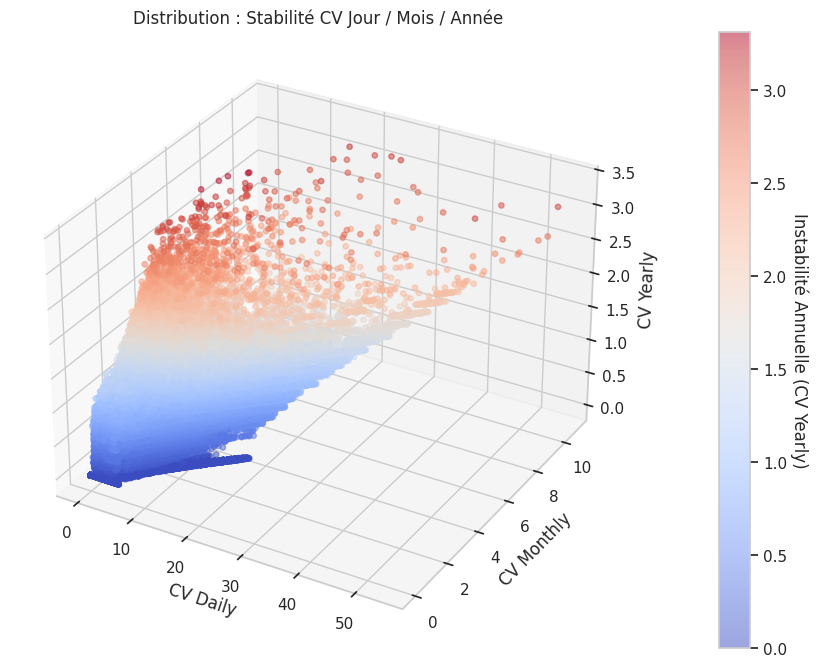

In [21]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# X=Daily, Y=Monthly, Z=Yearly. La couleur (c) dépend de Yearly pour bien voir l'anomalie annuelle.
scatter = ax.scatter(
    df_dispersion_combined['cv_daily'], 
    df_dispersion_combined['cv_monthly'], 
    df_dispersion_combined['cv_yearly'],
    c=df_dispersion_combined['cv_yearly'], 
    cmap='coolwarm', 
    alpha=0.5, 
    s=15
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Instabilité Annuelle (CV Yearly)', rotation=270, labelpad=15)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')
ax.set_title("Distribution : Stabilité CV Jour / Mois / Année")

plt.show()

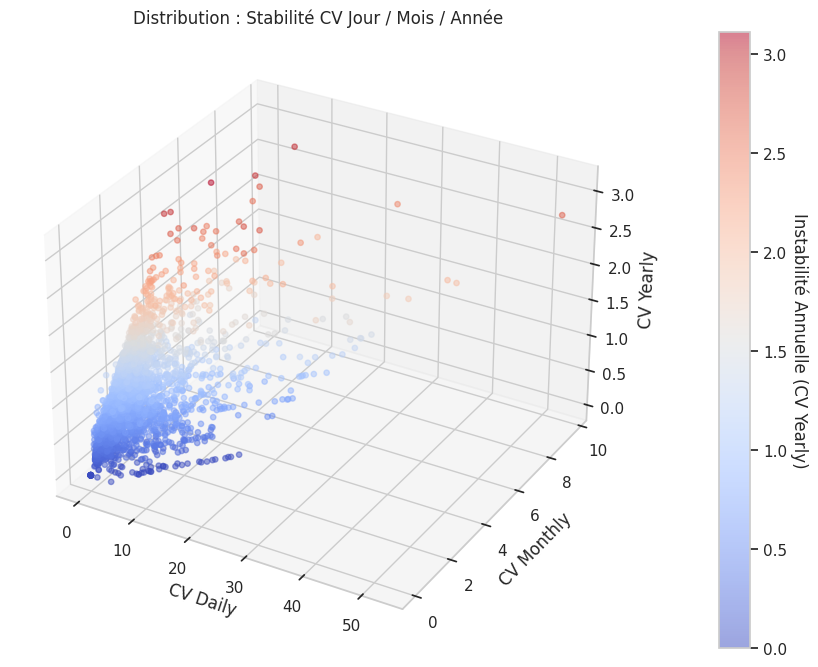

In [22]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# X=Daily, Y=Monthly, Z=Yearly. La couleur (c) dépend de Yearly pour bien voir l'anomalie annuelle.
scatter = ax.scatter(
    df_dispersion['cv_daily'], 
    df_dispersion['cv_monthly'], 
    df_dispersion['cv_yearly'],
    c=df_dispersion['cv_yearly'], 
    cmap='coolwarm', 
    alpha=0.5, 
    s=15
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Instabilité Annuelle (CV Yearly)', rotation=270, labelpad=15)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')
ax.set_title("Distribution : Stabilité CV Jour / Mois / Année")

plt.show()

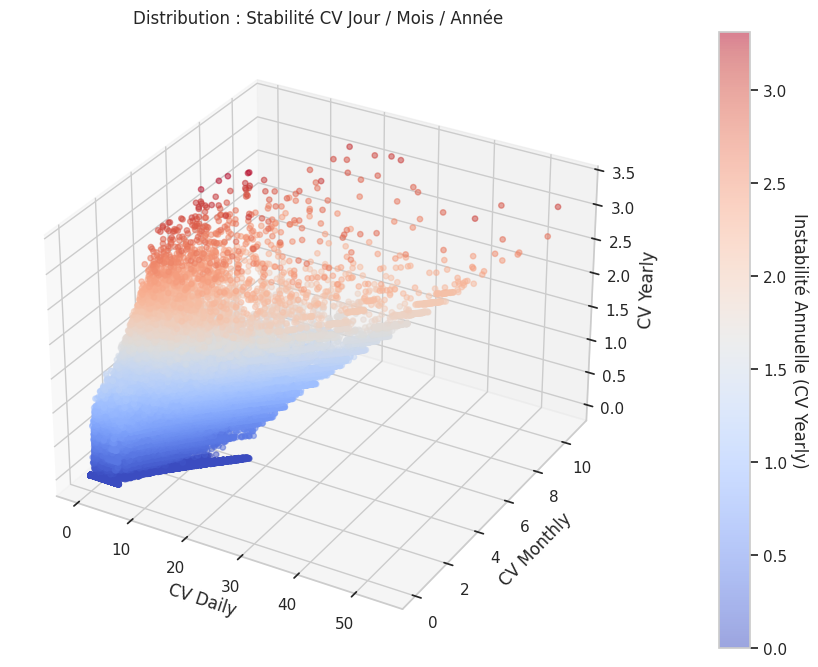

In [23]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# X=Daily, Y=Monthly, Z=Yearly. La couleur (c) dépend de Yearly pour bien voir l'anomalie annuelle.
scatter = ax.scatter(
    df_dispersion_inverse['cv_daily'], 
    df_dispersion_inverse['cv_monthly'], 
    df_dispersion_inverse['cv_yearly'],
    c=df_dispersion_inverse['cv_yearly'], 
    cmap='coolwarm', 
    alpha=0.5, 
    s=15
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Instabilité Annuelle (CV Yearly)', rotation=270, labelpad=15)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')
ax.set_title("Distribution : Stabilité CV Jour / Mois / Année")

plt.show()

Calcul sur un échantillon sécurisé de 3083 sources...
(Bridage des threads mathématiques activé pour éviter le crash du Kernel)


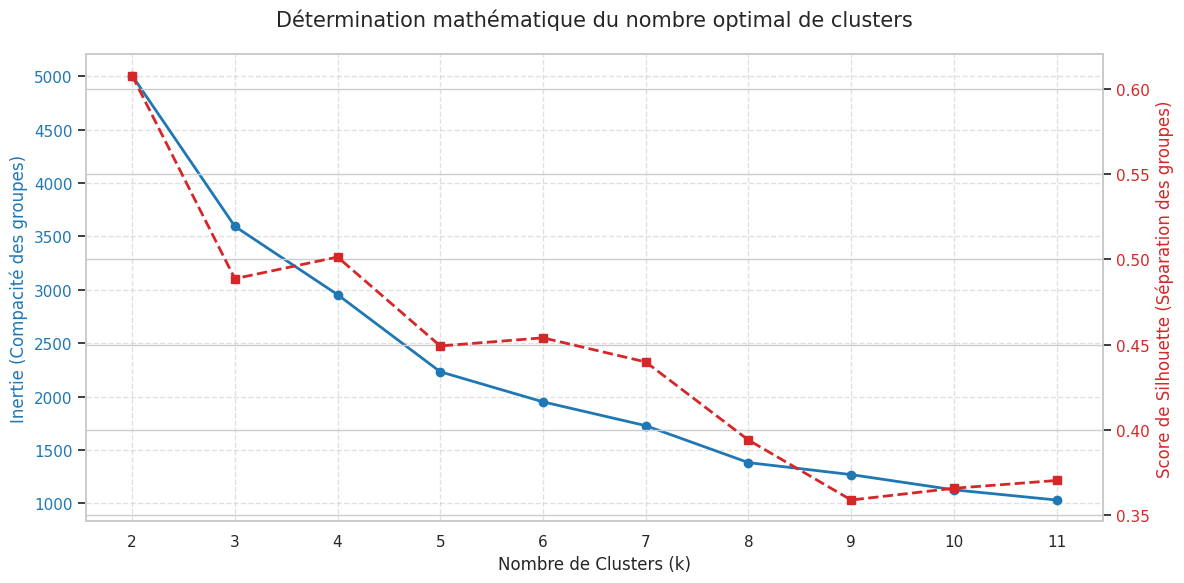

,Nombre de Clusters (k),Score de Silhouette
0,2,0.608033
2,4,0.501436
1,3,0.488721
4,6,0.453988
3,5,0.449207
5,7,0.439804
6,8,0.393945
9,11,0.370224
8,10,0.365639
7,9,0.358736


In [24]:
# Variables d'environnement en prévention absolue (si le kernel vient d'être redémarré)
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# 1. Préparation 
try:
    X_scaled
except NameError:
    from sklearn.preprocessing import StandardScaler
    X = df_dispersion[['cv_daily', 'cv_monthly', 'cv_yearly']].copy()
    X_scaled = StandardScaler().fit_transform(X)

# 2. Protection Anti-Crash : Échantillonnage préalable
np.random.seed(42)
max_samples = min(30000, X_scaled.shape[0])
indices = np.random.choice(X_scaled.shape[0], size=max_samples, replace=False)
X_scaled_sample = X_scaled[indices]

inertias = []
silhouette_scores = []
K_range = range(2, 12) 

print(f"Calcul sur un échantillon sécurisé de {max_samples} sources...")
print("(Bridage des threads mathématiques activé pour éviter le crash du Kernel)")

# 3. Calcul sous "haute protection"
# threadpool_limits force scikit-learn et numpy à n'utiliser qu'un seul coeur (ou très peu)
# ce qui empêche l'explosion de la RAM (OpenBLAS warning) pendant le KMeans.
with threadpool_limits(limits=1, user_api='blas'):
    with threadpool_limits(limits=1, user_api='openmp'):
        for k in K_range:
            # On entraîne le modèle sur l'échantillon réduit
            kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans_test.fit_predict(X_scaled_sample)
            
            # Inertie
            inertias.append(kmeans_test.inertia_)
            
            # Silhouette (déjà allégé puisque X_scaled_sample ne fait que 10k lignes)
            sil_score = silhouette_score(X_scaled_sample, labels, random_state=42)
            silhouette_scores.append(sil_score)

# ==========================================
# VISUALISATION DES DEUX MÉTRIQUES
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe 1 : L'inertie (Méthode du coude) - en bleu
color = 'tab:blue'
ax1.set_xlabel('Nombre de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertie (Compacité des groupes)', color=color, fontsize=12)
ax1.plot(K_range, inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()  

# Courbe 2 : Score de Silhouette - en rouge
color = 'tab:red'
ax2.set_ylabel('Score de Silhouette (Séparation des groupes)', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='dashed')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Détermination mathématique du nombre optimal de clusters", fontsize=15, pad=20)
fig.tight_layout()
plt.show()

# Affichage des scores de silhouette exacts
df_scores = pd.DataFrame({'Nombre de Clusters (k)': K_range, 'Score de Silhouette': silhouette_scores})
display(df_scores.sort_values('Score de Silhouette', ascending=False).style.background_gradient(cmap='Reds'))


Calcul sur un échantillon sécurisé de 3083 sources...
(Bridage des threads mathématiques activé pour éviter le crash du Kernel)


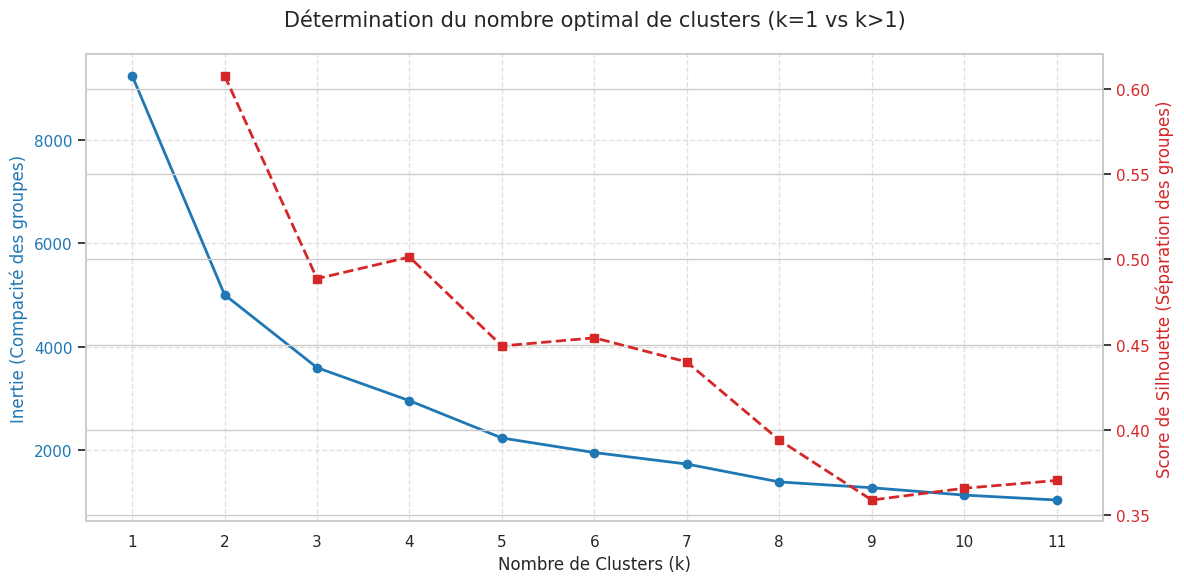


Tableau comparatif : Gain d'un découpage par rapport à un cluster unique (k=1) :


,Nombre de Clusters (k),Inertie,% Inertie Expliquée (vs k=1),Score de Silhouette
0,1,"9,249",0.0 %,N/A (Mathématiquement impossible)
1,2,"5,006",45.9 %,0.608
2,3,"3,594",61.1 %,0.489
3,4,"2,954",68.1 %,0.501
4,5,"2,231",75.9 %,0.449
5,6,"1,950",78.9 %,0.454
6,7,"1,727",81.3 %,0.440
7,8,"1,381",85.1 %,0.394
8,9,"1,269",86.3 %,0.359
9,10,"1,126",87.8 %,0.366


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from threadpoolctl import threadpool_limits

# Variables d'environnement en prévention absolue
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# 1. Préparation 
try:
    X_scaled
except NameError:
    from sklearn.preprocessing import StandardScaler
    X = df_dispersion[['cv_daily', 'cv_monthly', 'cv_yearly']].copy()
    X_scaled = StandardScaler().fit_transform(X)

# 2. Protection Anti-Crash : Échantillonnage préalable
np.random.seed(42)
max_samples = min(30000, X_scaled.shape[0])
indices = np.random.choice(X_scaled.shape[0], size=max_samples, replace=False)
X_scaled_sample = X_scaled[indices]

inertias = []
silhouette_scores = []
K_range = range(1, 12) 

print(f"Calcul sur un échantillon sécurisé de {max_samples} sources...")
print("(Bridage des threads mathématiques activé pour éviter le crash du Kernel)")

# 3. Calcul sous "haute protection" avec gestion spécifique de k=1
with threadpool_limits(limits=1, user_api='blas'):
    with threadpool_limits(limits=1, user_api='openmp'):
        for k in K_range:
            kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans_test.fit_predict(X_scaled_sample)
            
            # Inertie (fonctionne parfaitement pour k=1)
            inertias.append(kmeans_test.inertia_)
            
            # GESTION DU K=1 : Impossible de calculer la silhouette avec 1 seul groupe
            if k == 1:
                silhouette_scores.append(np.nan)
            else:
                sil_score = silhouette_score(X_scaled_sample, labels, random_state=42)
                silhouette_scores.append(sil_score)

# ==========================================
# VISUALISATION DES DEUX MÉTRIQUES
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe 1 : L'inertie (Méthode du coude) - en bleu
color = 'tab:blue'
ax1.set_xlabel('Nombre de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertie (Compacité des groupes)', color=color, fontsize=12)
ax1.plot(K_range, inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()  

# Courbe 2 : Score de Silhouette - en rouge (ignore automatiquement le np.nan à k=1)
color = 'tab:red'
ax2.set_ylabel('Score de Silhouette (Séparation des groupes)', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='dashed')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Détermination du nombre optimal de clusters (k=1 vs k>1)", fontsize=15, pad=20)
fig.tight_layout()
plt.show()

# ==========================================
# TABLEAU DE COMPÉTITION (k=1 vs AUTRES)
# ==========================================
# Calcul du % de gain par rapport au cluster unique (k=1)
inertie_k1 = inertias[0]
gain_variance = [(1 - (val / inertie_k1)) * 100 for val in inertias]

df_scores = pd.DataFrame({
    'Nombre de Clusters (k)': K_range,
    'Inertie': inertias,
    '% Inertie Expliquée (vs k=1)': gain_variance,
    'Score de Silhouette': silhouette_scores
})

print("\nTableau comparatif : Gain d'un découpage par rapport à un cluster unique (k=1) :")
display(df_scores.style \
        .format({
            'Inertie': '{:,.0f}',
            '% Inertie Expliquée (vs k=1)': '{:.1f} %',
            'Score de Silhouette': '{:.3f}'
        }, na_rep="N/A (Mathématiquement impossible)") \
        .background_gradient(subset=['% Inertie Expliquée (vs k=1)'], cmap='Blues') \
        .background_gradient(subset=['Score de Silhouette'], cmap='Reds'))

Calcul sur un échantillon sécurisé de 30000 sources...
(Bridage des threads mathématiques activé pour éviter le crash du Kernel)


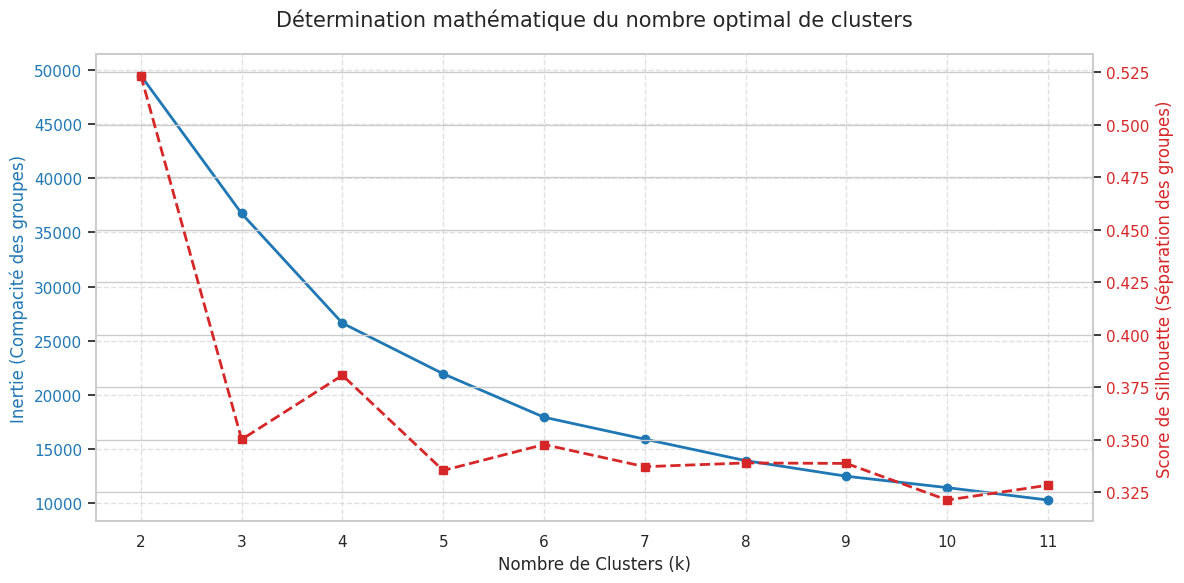

,Nombre de Clusters (k),Score de Silhouette
0,2,0.523495
2,4,0.380781
1,3,0.350230
4,6,0.347822
6,8,0.339052
7,9,0.338821
5,7,0.337266
3,5,0.335463
9,11,0.328436
8,10,0.321397


In [8]:
# Variables d'environnement en prévention absolue (si le kernel vient d'être redémarré)
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# # 1. Préparation 
# try:
#     X_scaled
# except NameError:
from sklearn.preprocessing import StandardScaler
X = df_dispersion_inverse[['cv_daily', 'cv_monthly', 'cv_yearly']].copy()
X_scaled = StandardScaler().fit_transform(X)

# 2. Protection Anti-Crash : Échantillonnage préalable
np.random.seed(42)
max_samples = min(30000, X_scaled.shape[0])
indices = np.random.choice(X_scaled.shape[0], size=max_samples, replace=False)
X_scaled_sample = X_scaled[indices]

inertias = []
silhouette_scores = []
K_range = range(2, 12) 

print(f"Calcul sur un échantillon sécurisé de {max_samples} sources...")
print("(Bridage des threads mathématiques activé pour éviter le crash du Kernel)")

# 3. Calcul sous "haute protection"
# threadpool_limits force scikit-learn et numpy à n'utiliser qu'un seul coeur (ou très peu)
# ce qui empêche l'explosion de la RAM (OpenBLAS warning) pendant le KMeans.
with threadpool_limits(limits=1, user_api='blas'):
    with threadpool_limits(limits=1, user_api='openmp'):
        for k in K_range:
            # On entraîne le modèle sur l'échantillon réduit
            kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
            labels = kmeans_test.fit_predict(X_scaled_sample)
            
            # Inertie
            inertias.append(kmeans_test.inertia_)
            
            # Silhouette (déjà allégé puisque X_scaled_sample ne fait que 10k lignes)
            sil_score = silhouette_score(X_scaled_sample, labels, random_state=42)
            silhouette_scores.append(sil_score)

# ==========================================
# VISUALISATION DES DEUX MÉTRIQUES
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe 1 : L'inertie (Méthode du coude) - en bleu
color = 'tab:blue'
ax1.set_xlabel('Nombre de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertie (Compacité des groupes)', color=color, fontsize=12)
ax1.plot(K_range, inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(K_range)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()  

# Courbe 2 : Score de Silhouette - en rouge
color = 'tab:red'
ax2.set_ylabel('Score de Silhouette (Séparation des groupes)', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='dashed')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Détermination mathématique du nombre optimal de clusters", fontsize=15, pad=20)
fig.tight_layout()
plt.show()

# Affichage des scores de silhouette exacts
df_scores = pd.DataFrame({'Nombre de Clusters (k)': K_range, 'Score de Silhouette': silhouette_scores})
display(df_scores.sort_values('Score de Silhouette', ascending=False).style.background_gradient(cmap='Reds'))


L'Inertie calcule la distance entre chaque média et le centre de son propre groupe.

Plus l'inertie est basse, plus les points du cluster sont rapprochés (denses).


Le Score de Silhouette calcule à quel point un média est proche des autres membres de son cluster ET à quel point il est éloigné du cluster voisin le plus proche.

Il ne suffit pas que le groupe soit serré, il faut aussi qu'il soit bien isolé des autres ! Le score va de -1 à 1 :

Proche de 1 : Parfait. Le point est au cœur de son cluster et très loin des autres.

Proche de 0 : Le point est à la frontière exacte entre deux clusters.

Proche de -1 : Le point a probablement été mis dans le mauvais cluster.

Bilan du K-Means (Segments GDELT) :


,Cluster_KMeans,%_Sources,%_Articles,Nb_Sources,Total_Articles,cv_daily,cv_monthly,cv_yearly,Exemples_Principaux
3,3,51.36 %,74.48 %,"2,695","390,108,477",1.08,0.59,0.49,"yahoo.com, indiatimes.com, msn.com, xinhuanet.com, bbc.com, udn.com, dailymail.co.uk, globo.com, uol.com.br, business-standard.com, china.com.cn, people.com.cn, ltn.com.tw, thehindu.com, dostor.org, sfgate.com, theguardian.com, regnum.ru, ansa.it, kompas.com"
0,0,35.58 %,23.19 %,"1,867","121,434,548",2.80,1.22,0.92,"sina.com.cn, reuters.com, tribunnews.com, wafa.ps, pikiran-rakyat.com, wickedlocal.com, menafn.com, huanqiu.com, lopinion.ma, philstar.com, merkur.de, obozrevatel.com, elpuntavui.cat, ahram.org.eg, news18.com, couriermail.com.au, haberturk.com, kreiszeitung.de, vetogate.com, chosun.com"
1,1,9.78 %,2.04 %,513,"10,675,417",4.85,2.32,1.58,"blogspot.com, ap.org, oem.com.mx, terra.com, terra.com.mx, goskagit.com, terra.com.pe, birgun.net, terra.com.co, businessdayonline.com, greenfieldreporter.com, dailyjanakantha.com, morningpost.com.cn, zjol.com.cn, medium.com, information.dk, bizjournals.com, jfdaily.com, franceinfo.fr, stuttgarter-nachrichten.de"
2,2,3.28 %,0.29 %,172,"1,537,908",17.00,3.81,1.23,"scotcampus.com, surenio.com.ar, gouv.bj, cardinalcourieronline.com, iranahayer.com, gallica.bnf.fr, onlymagazine.ca, banque-france.fr, michiganreview.com, litaliano.it, saba.ye, golos.com.ua, gaboteur.ca, matichon.co.th, portaldogoverno.gov.mz, langleyadvancetimes.com, dailyislam.pk, morgenbladet.no, bhutannewsservice.com, finnishcanadian.com"


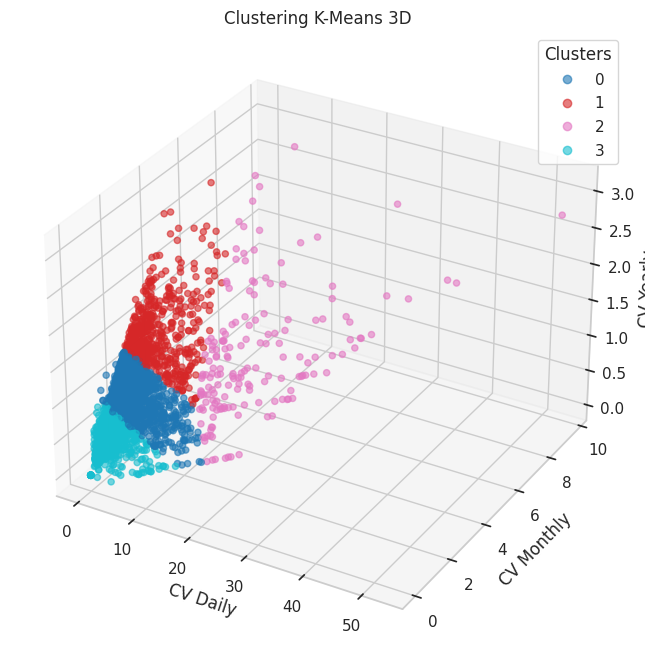

In [25]:
# 1. K-Means Clustering
X = df_dispersion[['cv_daily', 'cv_monthly', 'cv_yearly']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_dispersion['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# 2. Préparation des statistiques par cluster
# On calcule tout en une seule fois pour éviter les erreurs de renommage
stats_clusters = df_dispersion.groupby('Cluster_KMeans').agg(
    Nb_Sources=('Nom_Source', 'count'),
    Total_Articles=('total_articles', 'sum'),
    cv_daily=('cv_daily', 'mean'),
    cv_monthly=('cv_monthly', 'mean'),
    cv_yearly=('cv_yearly', 'mean')
)

# Extraction des exemples (Top 20)
exemples = df_dispersion.sort_values('total_articles', ascending=False).groupby('Cluster_KMeans')['Nom_Source'].apply(
    lambda x: ', '.join(x.head(20))
).reset_index().rename(columns={'Nom_Source': 'Exemples_Principaux'})

# 3. Fusion finale
bilan_complet = stats_clusters.merge(exemples, on='Cluster_KMeans')

# Calcul des pourcentages
tot_sources, tot_articles = bilan_complet['Nb_Sources'].sum(), bilan_complet['Total_Articles'].sum()
bilan_complet['%_Sources'] = (bilan_complet['Nb_Sources'] / tot_sources) * 100
bilan_complet['%_Articles'] = (bilan_complet['Total_Articles'] / tot_articles) * 100

# 4. Affichage final propre
colonnes = [
    'Cluster_KMeans', '%_Sources', '%_Articles', 'Nb_Sources', 
    'Total_Articles', 'cv_daily', 'cv_monthly', 'cv_yearly', 'Exemples_Principaux'
]

print("Bilan du K-Means (Segments GDELT) :")
display(bilan_complet[colonnes].sort_values('%_Articles', ascending=False).style.format({
    'cv_daily': '{:.2f}', 'cv_monthly': '{:.2f}', 'cv_yearly': '{:.2f}',
    'Nb_Sources': '{:,.0f}', 'Total_Articles': '{:,.0f}',
    '%_Sources': '{:.2f} %', '%_Articles': '{:.2f} %'
}).background_gradient(subset=['%_Articles'], cmap='Blues') \
  .background_gradient(subset=['%_Sources'], cmap='Purples'))
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_dispersion['cv_daily'], 
    df_dispersion['cv_monthly'], 
    df_dispersion['cv_yearly'],
    c=df_dispersion['Cluster_KMeans'], 
    cmap='tab10', 
    alpha=0.6
)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')

plt.title("Clustering K-Means 3D")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [26]:
df_dispersion[df_dispersion['Nom_Source'] == "mediapart.fr"]

,Src_ID,Nom_Source,total_articles,lifespan_days,lifespan_years,avg_daily,stddev_daily,cv_daily,avg_monthly,stddev_monthly,cv_monthly,avg_yearly,stddev_yearly,cv_yearly,Cluster_KMeans
67,29786,mediapart.fr,"5,830.00",4015,12,1.45,4.87,3.35,43.83,139.53,3.18,485.83,"1,456.61",3.00,2


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from threadpoolctl import threadpool_limits

# ---- 0. PROTECTION DU KERNEL ----
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

print("⏳ Nettoyage et préparation du sample inverse...")
# Nettoyage sans faire de copie inutile en RAM
df_dispersion_inverse = df_dispersion_inverse.dropna(subset=['cv_daily', 'cv_monthly', 'cv_yearly'])

# ---- 1. APPLICATION DU MODÈLE EXISTANT (SOUS BRIDAGE DE THREADS) ----
print("⏳ Calcul des clusters sous protection mémoire...")
with threadpool_limits(limits=1, user_api='blas'):
    with threadpool_limits(limits=1, user_api='openmp'):
        # On extrait directement en tableau NumPy pour économiser la RAM
        X_inv = df_dispersion_inverse[['cv_daily', 'cv_monthly', 'cv_yearly']].to_numpy()
        
        X_inv_scaled = scaler.transform(X_inv)
        df_dispersion_inverse['Cluster_KMeans'] = kmeans.predict(X_inv_scaled)

# ---- 2. PRÉPARATION DES STATISTIQUES PAR CLUSTER ----
print("⏳ Agrégation des statistiques sur 100% des données...")
stats_clusters_inv = df_dispersion_inverse.groupby('Cluster_KMeans').agg(
    Nb_Sources=('Nom_Source', 'count'),
    Total_Articles=('total_articles', 'sum'),
    cv_daily=('cv_daily', 'mean'),
    cv_monthly=('cv_monthly', 'mean'),
    cv_yearly=('cv_yearly', 'mean')
)

# Extraction optimisée des exemples (Top 20 du sample inverse)
# On trie uniquement les colonnes nécessaires avant le groupby pour alléger la mémoire
exemples_inv = (
    df_dispersion_inverse[['Cluster_KMeans', 'Nom_Source', 'total_articles']]
    .sort_values('total_articles', ascending=False)
    .groupby('Cluster_KMeans')['Nom_Source']
    .apply(lambda x: ', '.join(x.head(20)))
    .reset_index()
    .rename(columns={'Nom_Source': 'Exemples_Principaux'})
)

# ---- 3. FUSION ET CALCUL DES POURCENTAGES ----
bilan_complet_inv = stats_clusters_inv.merge(exemples_inv, on='Cluster_KMeans')

tot_sources_inv = bilan_complet_inv['Nb_Sources'].sum()
tot_articles_inv = bilan_complet_inv['Total_Articles'].sum()

bilan_complet_inv['%_Sources'] = (bilan_complet_inv['Nb_Sources'] / tot_sources_inv) * 100
bilan_complet_inv['%_Articles'] = (bilan_complet_inv['Total_Articles'] / tot_articles_inv) * 100

# ---- 4. AFFICHAGE DU BILAN INVERSE ----
colonnes = [
    'Cluster_KMeans', '%_Sources', '%_Articles', 'Nb_Sources', 
    'Total_Articles', 'cv_daily', 'cv_monthly', 'cv_yearly', 'Exemples_Principaux'
]

print("\n✅ Bilan du K-Means (Sample Inverse projeté sur les critères Wikidata) :")
display(bilan_complet_inv[colonnes].sort_values('%_Articles', ascending=False).style.format({
    'cv_daily': '{:.2f}', 'cv_monthly': '{:.2f}', 'cv_yearly': '{:.2f}',
    'Nb_Sources': '{:,.0f}', 'Total_Articles': '{:,.0f}',
    '%_Sources': '{:.2f} %', '%_Articles': '{:.2f} %'
}).background_gradient(subset=['%_Articles'], cmap='Blues') \
  .background_gradient(subset=['%_Sources'], cmap='Purples'))


⏳ Nettoyage et préparation du sample inverse...
⏳ Calcul des clusters sous protection mémoire...
⏳ Agrégation des statistiques sur 100% des données...

✅ Bilan du K-Means (Sample Inverse projeté sur les critères Wikidata) :


/home/clucas/venvs/gdelt/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Cluster_KMeans,%_Sources,%_Articles,Nb_Sources,Total_Articles,cv_daily,cv_monthly,cv_yearly,Exemples_Principaux
3,3,30.31 %,67.26 %,"38,999","630,769,818",2.97,0.70,0.35,"iheart.com, zazoom.it, haberler.com, finanznachrichten.de, sina.com.tw, eastmoney.com, cnfol.com, baomoi.com, ifeng.com, news.yam.md, naslovi.net, allafrica.com, prnewswire.com, sputniknews.com, 4-traders.com, chron.com, 20minutos.es, ria.ru, china.com, cfi.net.cn"
0,0,42.48 %,26.99 %,"54,662","253,080,814",5.82,1.41,0.70,"bjhmoh.cn, tvguide.co.uk, fasopresse.net, biztoc.com, inewsgr.com, sohu.com, 163.com, schoolloop.com, english.wafa.ps, kaixian.tv, joker.com, ziarelive.ro, dailypolitical.com, marketscreener.com, wkrb13.com, gwdtoday.com, lainformacion.com, news.dahe.cn, konhaber.com, themarketsdaily.com"
1,1,9.60 %,5.45 %,"12,358","51,140,028",6.42,2.36,1.45,"entornointeligente.com, gaeubote.de, asiaone.com, alarmeringen.nl, qq.com, tin247.com, usofarn.com, 247.libero.it, agenzianova.com, arabianewspaper.com, contacto-latino.com, sondakika.com, baidu.com, modernreaders.com, theenterpriseleader.com, fax.al, vu-online.li, chaspik.spb.ru, jndiario.com, hbrdr.com"
2,2,17.60 %,0.30 %,"22,647","2,770,180",18.25,3.49,0.90,"kamuturk.net, viewngr.com, elcentinelacatolico.org, amazonaws.com, tenthamendmentcenter.com, nieuwsbank.nl, maine207.org, newstrackindia.com, radyokabayan.com, oldschool1051.com, peruenlinea.pe, tygodnikjutrzenka.com, 987therock.com, caymanreporter.com, filkhbr.com, elyaomnews.com, pakasiatimes.com, singaporeinformer.com, nashfm923krst.com, codkamudug.com"


In [9]:
df_dispersion_inverse[df_dispersion_inverse['Nom_Source'] == "joker.com"]

,Src_ID,Nom_Source,total_articles,lifespan_days,lifespan_years,avg_daily,stddev_daily,cv_daily,avg_monthly,stddev_monthly,cv_monthly,avg_yearly,stddev_yearly,cv_yearly,Cluster_KMeans
69510,231442,joker.com,"1,255,580.00",510,3,"2,461.92","3,245.33",1.32,"69,754.44","90,189.58",1.29,"418,526.67","473,251.56",1.13,0


⏳ Génération du graphique 3D sécurisé...


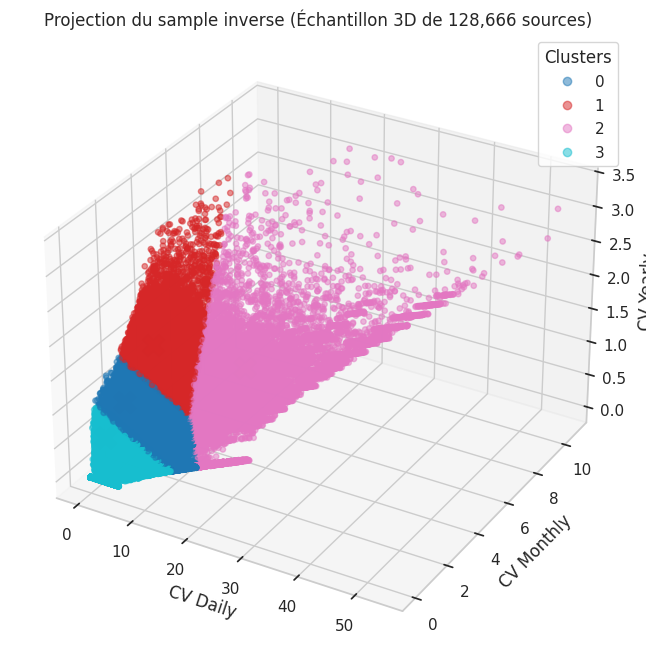

In [27]:

# ---- 5. VISUALISATION 3D SÉCURISÉE (ANTI-CRASH) ----
print("⏳ Génération du graphique 3D sécurisé...")

# SÉCURITÉ : On prend un sous-échantillon aléatoire de 15 000 points maximum pour Matplotlib
max_points_plot = 130830
if len(df_dispersion_inverse) > max_points_plot:
    print(f"⚠️ Volume trop élevé pour le rendu 3D ({len(df_dispersion_inverse):,.0f} sources). Affichage d'un échantillon aléatoire de {max_points_plot:,.0f} points.")
    df_plot = df_dispersion_inverse.sample(n=max_points_plot, random_state=42)
else:
    df_plot = df_dispersion_inverse

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_plot['cv_daily'], 
    df_plot['cv_monthly'], 
    df_plot['cv_yearly'],
    c=df_plot['Cluster_KMeans'], 
    cmap='tab10', 
    alpha=0.5,
    s=15  # Taille des points réduite pour mieux voir la densité
)

# Affichage des centres de gravité (centroïdes) du modèle original
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(
    centroides[:, 0], centroides[:, 1], centroides[:, 2],
    c='red', marker='X', s=250, label='Centroïdes originaux',
    edgecolors='black', linewidth=1.5
)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')

plt.title(f"Projection du sample inverse (Échantillon 3D de {len(df_plot):,.0f} sources)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

Bilan du K-Means (Segments GDELT) :


OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


,Cluster_KMeans,%_Sources,%_Articles,Nb_Sources,Total_Articles,cv_daily,cv_monthly,cv_yearly,Exemples_Principaux
1,1,81.89 %,97.93 %,"107,135","1,173,518,402",5.05,1.22,0.59,"iheart.com, yahoo.com, zazoom.it, indiatimes.com, tribunnews.com, reuters.com, haberler.com, finanznachrichten.de, sina.com.tw, eastmoney.com, bjhmoh.cn, cnfol.com, udn.com, dailymail.co.uk, globo.com, uol.com.br, entornointeligente.com, baomoi.com, ifeng.com, business-standard.com"
0,0,18.11 %,2.07 %,"23,695","24,839,599",16.52,3.54,1.22,"gaeubote.de, scotcampus.com, usofarn.com, agenzianova.com, arabianewspaper.com, surenio.com.ar, contacto-latino.com, blogspot.com, vu-online.li, chaspik.spb.ru, jndiario.com, hbrdr.com, kamuturk.net, businessdayonline.com, elbrqnews.com, dhakatoday.com, newsbookra.com, p23.com.ar, tipperarycrystal.ie, talkvietnam.com"


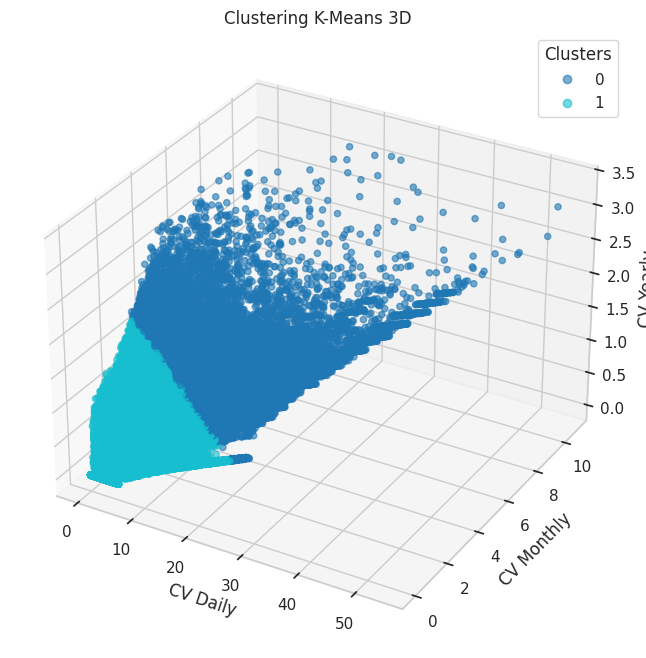

In [5]:
# 1. K-Means Clustering
X = df_dispersion_inverse[['cv_daily', 'cv_monthly', 'cv_yearly']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_dispersion_inverse['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# 2. Préparation des statistiques par cluster
# On calcule tout en une seule fois pour éviter les erreurs de renommage
stats_clusters = df_dispersion_inverse.groupby('Cluster_KMeans').agg(
    Nb_Sources=('Nom_Source', 'count'),
    Total_Articles=('total_articles', 'sum'),
    cv_daily=('cv_daily', 'mean'),
    cv_monthly=('cv_monthly', 'mean'),
    cv_yearly=('cv_yearly', 'mean')
)

# Extraction des exemples (Top 20)
exemples = df_dispersion_inverse.sort_values('total_articles', ascending=False).groupby('Cluster_KMeans')['Nom_Source'].apply(
    lambda x: ', '.join(x.head(20))
).reset_index().rename(columns={'Nom_Source': 'Exemples_Principaux'})

# 3. Fusion finale
bilan_complet = stats_clusters.merge(exemples, on='Cluster_KMeans')

# Calcul des pourcentages
tot_sources, tot_articles = bilan_complet['Nb_Sources'].sum(), bilan_complet['Total_Articles'].sum()
bilan_complet['%_Sources'] = (bilan_complet['Nb_Sources'] / tot_sources) * 100
bilan_complet['%_Articles'] = (bilan_complet['Total_Articles'] / tot_articles) * 100

# 4. Affichage final propre
colonnes = [
    'Cluster_KMeans', '%_Sources', '%_Articles', 'Nb_Sources', 
    'Total_Articles', 'cv_daily', 'cv_monthly', 'cv_yearly', 'Exemples_Principaux'
]

print("Bilan du K-Means (Segments GDELT) :")
display(bilan_complet[colonnes].sort_values('%_Articles', ascending=False).style.format({
    'cv_daily': '{:.2f}', 'cv_monthly': '{:.2f}', 'cv_yearly': '{:.2f}',
    'Nb_Sources': '{:,.0f}', 'Total_Articles': '{:,.0f}',
    '%_Sources': '{:.2f} %', '%_Articles': '{:.2f} %'
}).background_gradient(subset=['%_Articles'], cmap='Blues') \
  .background_gradient(subset=['%_Sources'], cmap='Purples'))

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_dispersion_inverse['cv_daily'], 
    df_dispersion_inverse['cv_monthly'], 
    df_dispersion_inverse['cv_yearly'],
    c=df_dispersion_inverse['Cluster_KMeans'], 
    cmap='tab10', 
    alpha=0.6
)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')

plt.title("Clustering K-Means 3D")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [10]:
df_gold = df_dispersion[df_dispersion['Cluster_KMeans'].isin([1])].copy()

# On crée aussi le complément (le "bruit" ou "zone d'étude secondaire")
df_noise = df_dispersion[~df_dispersion['Cluster_KMeans'].isin([1])].copy()

print(f"Vue 'Gold Standard' créée : {len(df_gold):,} sources conservées.")
print(f"Médias exclus (Cluster 0, 2, 3) : {len(df_noise):,} sources écartées.")

Vue 'Gold Standard' créée : 65,447 sources conservées.
Médias exclus (Cluster 0, 2, 3) : 68,466 sources écartées.


In [11]:
df_gold.head(30)

,Src_ID,Nom_Source,total_articles,lifespan_days,lifespan_years,avg_daily,stddev_daily,cv_daily,avg_monthly,stddev_monthly,cv_monthly,avg_yearly,stddev_yearly,cv_yearly,Cluster_KMeans
28141,27269,samsunhaberleri.com,"10,863.00",473,2,22.97,67.72,2.95,639.00,"1,446.26",2.26,"5,431.50","2,784.50",0.51,1
28602,202782,turkeytelegraph.com,678.00,495,2,1.37,4.80,3.51,39.88,89.43,2.24,339.00,199.00,0.59,1
29507,288019,thecatholicherald.com,471.00,433,2,1.09,3.72,3.42,31.40,70.17,2.23,235.50,148.50,0.63,1
30044,171541,rejstriky.finance.cz,171.00,670,3,0.26,0.92,3.62,7.43,16.41,2.21,57.00,38.88,0.68,1
30096,152799,mareainformativa.com,476.00,704,3,0.68,2.23,3.30,19.83,43.71,2.20,158.67,93.60,0.59,1
31182,35333,elazighaberim.com,534.00,497,2,1.07,3.05,2.84,29.67,63.96,2.16,267.00,87.00,0.33,1
31536,150667,marketexclusive.com,"2,418.00",1174,4,2.06,6.49,3.15,62.00,132.88,2.14,604.50,370.29,0.61,1
31610,31285,rumbotx.com,155.00,470,2,0.33,1.02,3.08,9.12,19.51,2.14,77.50,34.50,0.45,1
31673,175580,snewsi.com,"2,544.00",947,4,2.69,9.52,3.55,79.50,169.94,2.14,636.00,426.72,0.67,1
31686,261713,alaraby.com,63.00,286,2,0.22,0.71,3.23,5.73,12.24,2.14,31.50,14.50,0.46,1


## Sources : Wordcounts

In [2]:
print("1. Calcul des statistiques de Wordcount par source...")

query_wc = """
    WITH wc_stats AS (
        SELECT 
            Src_ID,
            COUNT(*) AS total_articles,
            AVG(CAST(WordCount AS DOUBLE)) AS avg_wordcount,
            -- STDDEV_POP calcule directement l'écart-type sur toute la population
            STDDEV_POP(CAST(WordCount AS DOUBLE)) AS stddev_wordcount
        FROM gkg_raw
        WHERE WordCount IS NOT NULL
        GROUP BY 1
    )
    SELECT 
        w.Src_ID,
        m.SourceCommonName AS Nom_Source,
        w.total_articles,
        w.avg_wordcount,
        w.stddev_wordcount,
        -- Calcul du Coefficient de Variation (CV = Ecart-type / Moyenne)
        CASE WHEN w.avg_wordcount > 0 THEN w.stddev_wordcount / w.avg_wordcount ELSE 0 END AS cv_wordcount
    FROM wc_stats w
    JOIN src_map m ON w.Src_ID = m.Src_ID
    -- On filtre pour ne garder que les sources ayant un minimum de volume (ex: 50 articles)
    WHERE w.total_articles > 50
"""

df_wordcount = con.execute(query_wc).df()

df_wordcount.to_parquet('sources_wordcount_stats_raw.parquet', index=False)
print("Statistiques calculées et sauvegardées")

1. Calcul des statistiques de Wordcount par source...
Statistiques calculées et sauvegardées


2. Génération du graphique 3D...


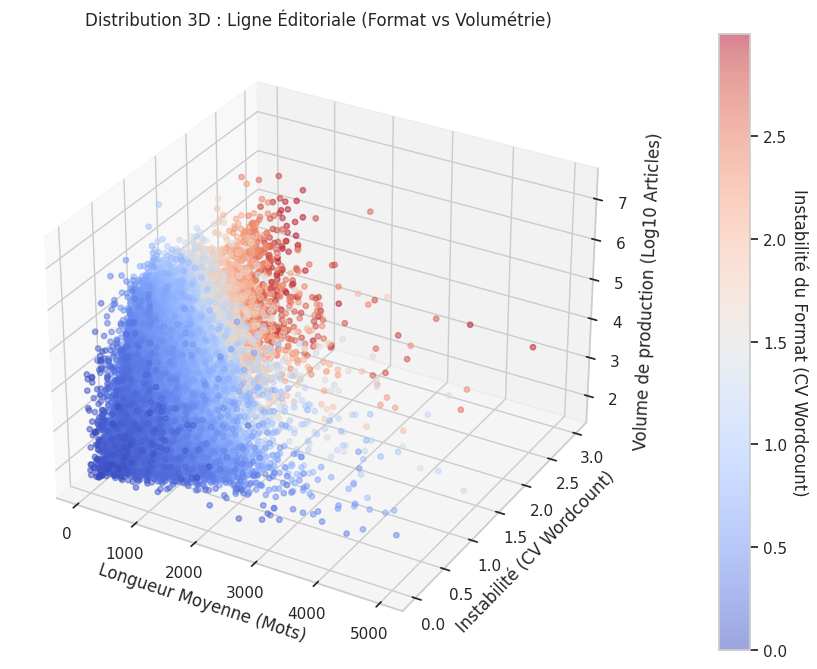

In [5]:
print("2. Génération du graphique 3D...")

# ---------------------------------------------------------
# FILTRAGE ANTI-BRUIT POUR LA VISUALISATION
# GDELT contient parfois des erreurs de parsing (des articles de 500 000 mots).
# On limite l'affichage aux articles de moins de 5000 mots pour y voir clair.
# ---------------------------------------------------------
df_visu = df_wordcount[
    (df_wordcount['avg_wordcount'] < 5000) & 
    (df_wordcount['cv_wordcount'] < 3)
].copy()

# Création de la figure 3D dans le même esprit que ton code
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# L'axe Z représente le volume d'articles. 
# On utilise le logarithme (np.log10) pour que les médias à 1 milliard d'articles 
# n'écrasent pas visuellement les médias à 10 000 articles.
z_axis = np.log10(df_visu['total_articles'])

scatter = ax.scatter(
    df_visu['avg_wordcount'],   # X : Longueur moyenne
    df_visu['cv_wordcount'],    # Y : Instabilité du format
    z_axis,                     # Z : Puissance de publication
    c=df_visu['cv_wordcount'],  # Couleur basée sur l'instabilité (CV)
    cmap='coolwarm', 
    alpha=0.5, 
    s=15
)

# Barre de couleur latérale
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Instabilité du Format (CV Wordcount)', rotation=270, labelpad=15)

# Étiquettes des axes
ax.set_xlabel('Longueur Moyenne (Mots)')
ax.set_ylabel('Instabilité (CV Wordcount)')
ax.set_zlabel('Volume de production (Log10 Articles)')
ax.set_title("Distribution 3D : Ligne Éditoriale (Format vs Volumétrie)")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



print("🧠 2. Clustering K-Means des formats éditoriaux...")

# On ajoute le Log du volume pour que l'IA prenne en compte la taille du média sans être écrasée par les géants
df_wordcount['log_volume'] = np.log10(df_wordcount['total_articles'])

# Standardisation des 3 axes
X = df_wordcount[['avg_wordcount', 'cv_wordcount', 'log_volume']].copy()
X_scaled = StandardScaler().fit_transform(X)

# Application du K-Means (On part sur 5 clusters arbitraires pour commencer)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_wordcount['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)


🧠 2. Clustering K-Means des formats éditoriaux...


📋 3. Bilan des clusters de contenu (Wordcount) :


,Cluster_KMeans,%_Sources,%_Articles,Nb_Sources,Total_Articles,avg_wordcount,cv_wordcount,Exemples_Principaux
3,3,39.98 %,95.21 %,"24,879","1,364,506,554",393 mots,0.86,"iheart.com, yahoo.com, zazoom.it, sina.com.cn, indiatimes.com, msn.com, tribunnews.com, reuters.com, haberler.com, sina.com.tw, eastmoney.com, bjhmoh.cn, cnfol.com, udn.com, dailymail.co.uk, globo.com, uol.com.br, entornointeligente.com, baomoi.com, ifeng.com"
0,0,3.84 %,3.25 %,"2,389","46,618,836",400 mots,2.43,"finanznachrichten.de, news.yam.md, welt.de, setn.com, marketscreener.com, t-online.de, investegate.co.uk, korrespondent.net, focus-news.net, unitaangola.org, nccbmwcca.org, wn.com, echo.msk.ru, faz.net, ksta.de, wallstreet-online.de, blogspot.com, streetinsider.com, rundschau-online.de, lessentiel.lu"
1,1,50.72 %,0.95 %,"31,557","13,593,318",425 mots,0.70,"itclat.com, masterherald.com, ibusinesslines.com, newsleading.info, eahelqesa.com, piercepioneer.com, assercourant.nl, proexpansion.com, joshnaijablog.com, emarketsdaily.com, whatifthe.com, day-news.net, nationalnewsarticles.com, nytsyn.com, horseracing.com.au, thepolypost.com, andhra.indiaeveryday.in, gizpress.com, scienmag.com, aspistrategist.org.au"
2,2,5.46 %,0.59 %,"3,399","8,406,732",1468 mots,0.78,"cfi.net.cn, pressan.is, seekingalpha.com, funkytaurusmedia.com, fax.al, chaspik.spb.ru, sys-con.com, huxiu.com, catholicsentinel.org, telegram.com, tmtpost.com, wsws.org, cadillacnews.com, minghui.org, azadliq.az, qstheory.cn, nt.am, theatlantic.com, healio.com, eeo.com.cn"


📊 4. Génération du graphique 3D par clusters...


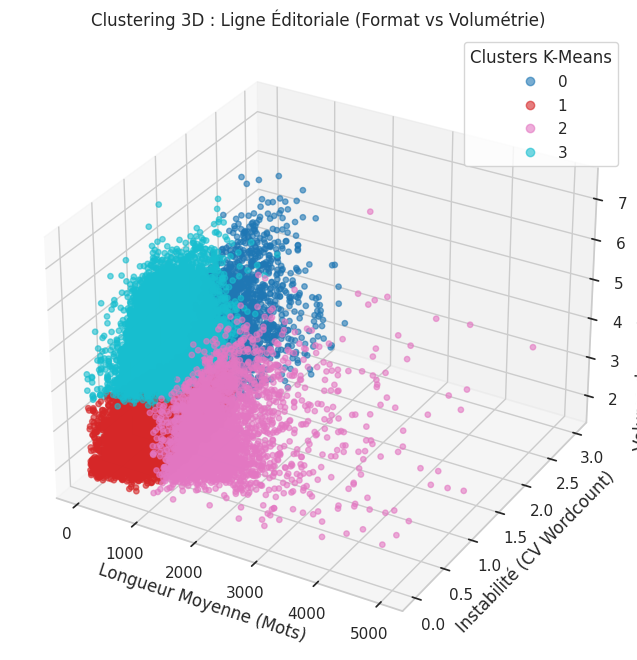

In [20]:


print("📋 3. Bilan des clusters de contenu (Wordcount) :")

# Calcul des statistiques par cluster
stats_clusters = df_wordcount.groupby('Cluster_KMeans').agg(
    Nb_Sources=('Nom_Source', 'count'),
    Total_Articles=('total_articles', 'sum'),
    avg_wordcount=('avg_wordcount', 'mean'),
    cv_wordcount=('cv_wordcount', 'mean')
)

# Extraction des exemples (Top 20)
exemples = df_wordcount.sort_values('total_articles', ascending=False).groupby('Cluster_KMeans')['Nom_Source'].apply(
    lambda x: ', '.join(x.head(20))
).reset_index().rename(columns={'Nom_Source': 'Exemples_Principaux'})

# Fusion et calcul des pourcentages
bilan_complet = stats_clusters.merge(exemples, on='Cluster_KMeans')
tot_sources, tot_articles = bilan_complet['Nb_Sources'].sum(), bilan_complet['Total_Articles'].sum()
bilan_complet['%_Sources'] = (bilan_complet['Nb_Sources'] / tot_sources) * 100
bilan_complet['%_Articles'] = (bilan_complet['Total_Articles'] / tot_articles) * 100

# Affichage propre
colonnes = [
    'Cluster_KMeans', '%_Sources', '%_Articles', 'Nb_Sources', 
    'Total_Articles', 'avg_wordcount', 'cv_wordcount', 'Exemples_Principaux'
]

display(bilan_complet[colonnes].sort_values('%_Articles', ascending=False).style.format({
    'avg_wordcount': '{:.0f} mots', 
    'cv_wordcount': '{:.2f}',
    'Nb_Sources': '{:,.0f}', 
    'Total_Articles': '{:,.0f}',
    '%_Sources': '{:.2f} %', 
    '%_Articles': '{:.2f} %'
}).background_gradient(subset=['%_Articles'], cmap='Blues') \
  .background_gradient(subset=['avg_wordcount'], cmap='Purples'))


print("📊 4. Génération du graphique 3D par clusters...")

# Filtrage anti-bruit pour la visualisation 3D
df_visu = df_wordcount[
    (df_wordcount['avg_wordcount'] < 5000) & 
    (df_wordcount['cv_wordcount'] < 3)
].copy()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

z_axis_visu = np.log10(df_visu['total_articles'])

# Nuage de points coloré par Cluster
scatter = ax.scatter(
    df_visu['avg_wordcount'],   # X : Longueur moyenne
    df_visu['cv_wordcount'],    # Y : Instabilité du format
    z_axis_visu,                # Z : Puissance de publication
    c=df_visu['Cluster_KMeans'],# Couleur = Le cluster d'appartenance
    cmap='tab10',               # tab10 = Palette de couleurs discrètes
    alpha=0.6, 
    s=15
)

ax.set_xlabel('Longueur Moyenne (Mots)')
ax.set_ylabel('Instabilité (CV Wordcount)')
ax.set_zlabel('Volume de production (Log10 Articles)')
ax.set_title("Clustering 3D : Ligne Éditoriale (Format vs Volumétrie)")

# Ajout de la légende des clusters
plt.legend(*scatter.legend_elements(), title="Clusters K-Means")
plt.show()